### Dataset preparation    
#### Convert water vector to raster image. 


In [ ]:
from glob import glob
import rasterio as rio 
import geopandas as gpd
from pyrsimg import imgShow
from pyrsimg.raster_vec import vec2mask
import matplotlib.pyplot as plt


In [26]:
dir_truth_gpkg = 'data/dset/truth/truth_gpkg'
dir_truth_tif = 'data/dset/truth/truth_tif'
dir_scene = 'data/dset/scene/scene_ori'
### get the secene and truth pairwise data
paths_scene = sorted(glob(dir_scene+'/*/*.tif'))
paths_truth_gpkg = sorted(glob(dir_truth_gpkg+'/*/*.gpkg'))
print(len(paths_scene))
print(len(paths_truth_gpkg)) 
print(paths_scene[19])
print(paths_truth_gpkg[19]) 


65
65
data/dset/scene/scene_ori/l7/l7_scene_07.tif
data/dset/truth/truth_gpkg/l7/l7_scene_07_truth.gpkg


In [27]:
## check the pair-wise scene images and the truth vector
id_dset = 6
scene_rio = rio.open(paths_scene[id_dset])
truth_vec_gpd = gpd.read_file(paths_truth_gpkg[id_dset])
scene_extent = [scene_rio.bounds.left, scene_rio.bounds.right, 
                scene_rio.bounds.bottom, scene_rio.bounds.top]
print(paths_scene[id_dset])
print(paths_truth_gpkg[id_dset])  


data/dset/scene/scene_ori/l5/l5_scene_07.tif
data/dset/truth/truth_gpkg/l5/l5_scene_07_truth.gpkg


<Axes: >

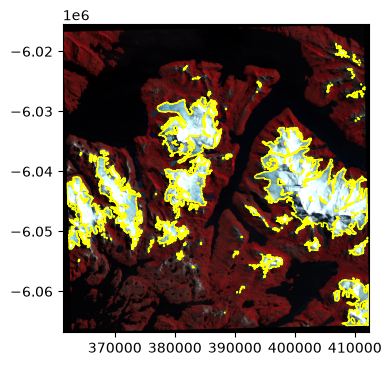

In [28]:
if scene_rio.crs != truth_vec_gpd.crs:
    print('crs transformation needed')
    truth_vec_gpd = truth_vec_gpd.to_crs(scene_rio.crs.to_dict())
## show the scene and the truth vector
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
imgShow(scene_rio.read([2,3,4]).transpose(1,2,0), 
            ax=ax, clip_percent=5, extent=scene_extent)
truth_vec_gpd.plot(ax=ax, color='None', edgecolor='yellow', linewidth=1)


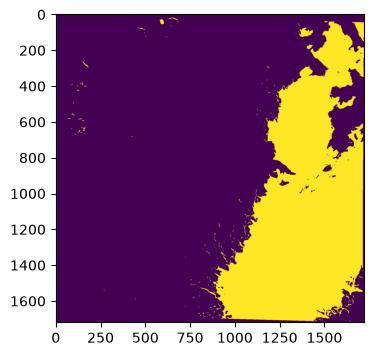

In [29]:
i = 9
path_truth_tif = paths_truth_gpkg[i].replace('gpkg', 'tif')
mask_water = vec2mask(path_vec=paths_truth_gpkg[i], 
                      path_raster=paths_scene[i], path_save = path_truth_tif)
plt.figure(figsize=(4, 4))
plt.imshow(mask_water)  


In [30]:
for i, path_truth_gpkg in enumerate(paths_truth_gpkg):
    path_truth_tif = path_truth_gpkg.replace('gpkg', 'tif')
    path_scene_tif = paths_scene[i]
    _ = vec2mask(path_vec=path_truth_gpkg, 
                path_raster=path_scene_tif, path_save = path_truth_tif)
    print('mask saved to: ', path_truth_tif) 
    

mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_01_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_02_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_03_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_04_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_05_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_06_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_07_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_08_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_09_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_10_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_11_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_12_truth.tif
mask saved to:  data/dset/truth/truth_tif/l5/l5_scene_13_truth.tif
mask saved to:  data/dset/truth/truth_tif/l7/l7_scene_01_truth.tif
mask saved to:  data/dset/truth/truth_tif/l7/l7_scene_02_truth